In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn .metrics import accuracy_score
from sklearn.datasets import make_circles
import pandas as pd

In [2]:
# Raw Data 
X,y = make_circles(
    n_samples=300,
    noise=0.05,
    random_state=42,
    factor=0.3
)
y= np.where(y==0,-1,1)

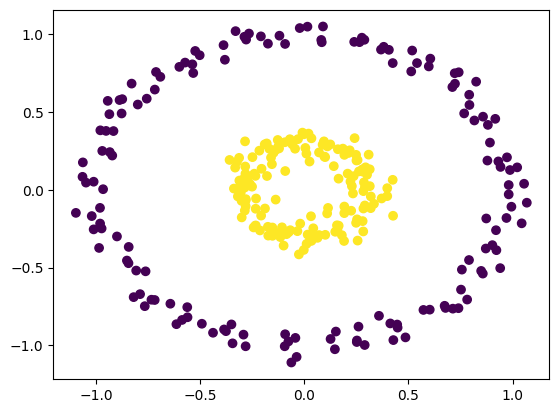

In [3]:
plt.scatter(X[:,0], X[:,1], c=y)

We cant fit a stright line for this data 

so we transform it

In [4]:
# Original:
# [x1,x2]

# Transform into:
# [x1,x2,x1²,x2²,x1*x2]


X_poly = np.column_stack([

    X[:,0],
    X[:,1],

    X[:,0]**2,
    X[:,1]**2,

    X[:,0]*X[:,1]

])


In [5]:
class SVM:
    def __init__(self,alpha=0.001,lambda_param=0.01,epochs=1000):
        self.alpha = alpha
        self.lambda_param=lambda_param
        self.epochs=epochs
    
    def fit(self,X,y):
        n_samples,n_features=X.shape
        self.w=np.zeros(n_features)
        self.b=0

        for epoch in range(self.epochs):
            for idx,x_i in enumerate(X):
                condition = y[idx]*(np.dot(x_i,self.w)+self.b)>=1
                if condition:
                    dw = 2*self.lambda_param*self.w
                    db=0
                else:
                    dw = (2*self.lambda_param*self.w - y[idx]*x_i)
                    db = - y[idx]
                self.w -= self.alpha*dw
                self.b -= self.alpha*db
    
    def predict(self,X):
        linear = np.dot(X, self.w)+self.b
        return np.sign(linear)


In [6]:
model = SVM()
model.fit(X_poly,y)
predictions = model.predict(X_poly)
accuracy = np.mean(
    predictions == y
)
print(
    "Accuracy:",
    accuracy
)

Accuracy: 1.0


In [8]:
import plotly.express as px
import plotly.graph_objects as go

# We project the 2D data into 3D using x1^2 + x2^2 for the z-axis
df = pd.DataFrame({
    'x1': X[:, 0],
    'x2': X[:, 1],
    'z': X[:, 0]**2 + X[:, 1]**2,
    'class': y.astype(str)
})

fig = px.scatter_3d(df, x='x1', y='x2', z='z', color='class', title='3D Projection of Transformed Data with Hyperplane')

# The SVM hyperplane equation is: w0*x1 + w1*x2 + w2*x1^2 + w3*x2^2 + w4*x1*x2 + b = 0
# Notice that z = x1^2 + x2^2. We can approximate w2*x1^2 + w3*x2^2 as w_mean * z.
w_mean = (model.w[2] + model.w[3]) / 2

# Create a meshgrid for x1 and x2
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)
xx, yy = np.meshgrid(x_range, y_range)

# Calculate the z values for the hyperplane plane: z = (-w0*x1 - w1*x2 - w4*x1*x2 - b) / w_mean
if abs(w_mean) > 1e-5:
    zz = (-model.w[0]*xx - model.w[1]*yy - model.w[4]*xx*yy - model.b) / w_mean
else:
    zz = np.zeros_like(xx)

# Add the hyperplane surface to the figure
fig.add_trace(go.Surface(x=xx, y=yy, z=zz, opacity=0.4, colorscale='Ice', name='Hyperplane', showscale=False))

fig.show()